## Plotting synthesised samples from the CCVAE network

In [116]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import csv

In [117]:
colourmap = cm.inferno(np.linspace(0, 1, 10))

In [118]:
def get_record(csv_file, row):
    """
    Get a specific row from csv file as a python list
    """
    with open(csv_file) as file:
        reader = csv.reader(file)
        record = next(i for row_number, i in enumerate(reader) if row_number == row)
    
    return record

def get_spectra(record):
    """
    From a python list, get the values at each wavelength and return both wavelength and reflectance
    """
    wavelengths = [wl for wl in range(400, 2491, 10)]
    reflectance = []
    for i in range(400, 2491, 10):
        index = int(((i-400)/10) + 7)
        reflectance.append(float(record[index]))

    return wavelengths, reflectance

In [119]:
# Test to see if it works
r = get_record('ccvaegenerated_ccvae.csv', 0)
wl, ref = get_spectra(r)
print(r)
print(ref)
print(wl)

['Spectra', 'gv_fraction', 'npv_fraction', 'soil_fraction', 'RWC index', 'Calculated RWC', 'use', '400', '410', '420', '430', '440', '450', '460', '470', '480', '490', '500', '510', '520', '530', '540', '550', '560', '570', '580', '590', '600', '610', '620', '630', '640', '650', '660', '670', '680', '690', '700', '710', '720', '730', '740', '750', '760', '770', '780', '790', '800', '810', '820', '830', '840', '850', '860', '870', '880', '890', '900', '910', '920', '930', '940', '950', '960', '970', '980', '990', '1000', '1010', '1020', '1030', '1040', '1050', '1060', '1070', '1080', '1090', '1100', '1110', '1120', '1130', '1140', '1150', '1160', '1170', '1180', '1190', '1200', '1210', '1220', '1230', '1240', '1250', '1260', '1270', '1280', '1290', '1300', '1310', '1320', '1330', '1340', '1350', '1360', '1370', '1380', '1390', '1400', '1410', '1420', '1430', '1440', '1450', '1460', '1470', '1480', '1490', '1500', '1510', '1520', '1530', '1540', '1550', '1560', '1570', '1580', '1590', '1

In [120]:
# plotting code

def get_data(sample_no):
    r = get_record('ccvaegenerated_ccvae.csv', sample_no)
    wl, ref = get_spectra(r)
    name = r[0]
    ab = (r[1], r[2], r[3])

    return name, ab, wl, ref

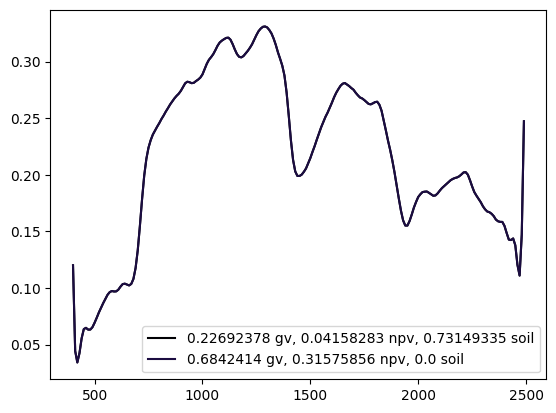

In [121]:
fig = plt.figure()
ax1 = plt.subplot(1,1,1)
# ax2 = plt.subplot(10,1,2)
# ax3 = plt.subplot(10,1,3)
# ax4 = plt.subplot(10,1,4)
# ax5 = plt.subplot(10,1,5)
# ax6 = plt.subplot(10,1,6)
# ax7 = plt.subplot(10,1,7)
# ax8 = plt.subplot(10,1,8)
# ax9 = plt.subplot(10,1,9)
# ax10 = plt.subplot(10,1,10)

name1, ab1, wl1, ref1 = get_data(10)
name2, ab2, wl2, ref2 = get_data(1000)
ax1.plot(wl1, ref1, color = colourmap[0], label=f'{ab1[0]} gv, {ab1[1]} npv, {ab1[2]} soil')
ax1.plot(wl2, ref2, color = colourmap[1], label=f'{ab2[0]} gv, {ab2[1]} npv, {ab2[2]} soil')
# ax1.plot(wl1, ref1, color = colourmap[0], label=f'{ab1[0]} gv, {ab1[1]} npv, {ab1[2]} soil')
# ax1.plot(wl2, ref2, color = colourmap[1], label=f'{ab2[0]} gv, {ab2[1]} npv, {ab2[2]} soil')
ax1.legend()

plt.show()